In [ ]:
# =====================================================================================
# Bottom-Up Credit Strategy in finding bonds are relatively undervalued or overvalued
# Steps: use reduced form or structural models to estimate a specific company bond's
# probability of default, then compare with its market-implied prob of default, and
# make credit strategy based on the comparison.
# =====================================================================================

In [ ]:
# =====================================================================================
# PART A: Reduced MODEL (Use financial ratios and recovery assumptions in regression)
# =====================================================================================

In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt


# ======================================================
# METHOD 1: SIMULATION ("God Mode")
# With Train/Test Split (70/30)
# ======================================================

# ======================================================
# 1: Modeling
# ======================================================
print("--- RUNNING METHOD 1: SIMULATION (Train/Test Split) ---")
np.random.seed(101)
n_samples = 2000

# 1. Generate Synthetic Data
data = {
    'leverage': np.random.normal(0.40, 0.15, n_samples),      # Debt/Capital
    'profitability': np.random.normal(0.10, 0.05, n_samples), # EBITDA/Assets
    'coverage': np.random.lognormal(1.0, 0.5, n_samples),     # EBITDA/Interest
    'volatility': np.random.normal(0.30, 0.10, n_samples)     # Trailing 12m Vol
}
df_sim = pd.DataFrame(data)

# 2. Define "Ground Truth" Logic
# Coefficients: Lev (+4), Prof (-6), Cov (-0.8), Vol (+2.5)
logit_z = (4.0 * df_sim['leverage']
           - 6.0 * df_sim['profitability']
           - 0.8 * df_sim['coverage']
           + 2.5 * df_sim['volatility']
           - 1.5)

prob = 1 / (1 + np.exp(-logit_z))
df_sim['default'] = (np.random.rand(n_samples) < prob).astype(int)

# 3. Split Data (70% Train, 30% Test)
X = df_sim[['leverage', 'profitability', 'coverage', 'volatility']]
y = df_sim['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Estimate Model on TRAINING Data
X_train_sm = sm.add_constant(X_train)
model_sim = sm.Logit(y_train, X_train_sm).fit(disp=0)

# 5. Predict on TEST Data
X_test_sm = sm.add_constant(X_test)
df_test_results = X_test.copy()
df_test_results['Model_PD'] = model_sim.predict(X_test_sm)

# 6. Show Results
print(model_sim.summary())

print("\n--- Method 1: Riskiest (from Test Set) ---")
# Sorting to show the model is working correctly
print(df_test_results.sort_values('Model_PD', ascending=False).iloc[[0, 1, 2]])


print("\n--- Method 1: Safest (from Test Set) ---")
# Sorting to show the model is working correctly
print(df_test_results.sort_values('Model_PD', ascending=False).iloc[[-3, -2, -1]])





--- RUNNING METHOD 1: SIMULATION (Train/Test Split) ---
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 1400
Model:                          Logit   Df Residuals:                     1395
Method:                           MLE   Df Model:                            4
Date:                Sat, 03 Jan 2026   Pseudo R-squ.:                  0.1894
Time:                        00:05:07   Log-Likelihood:                -508.25
converged:                       True   LL-Null:                       -627.02
Covariance Type:            nonrobust   LLR p-value:                 3.158e-50
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.4007      0.409     -3.423      0.001      -2.203      -0.599
leverage          4.0368      0.530      7.620      0.000       2.

In [30]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
from ucimlrepo import fetch_ucirepo

# ======================================================
# METHOD 2: INDUSTRY DATA (UCI Proxy)
# ======================================================
print("\n--- METHOD 2: INDUSTRY DATA (UCI) ---")
dataset = fetch_ucirepo(id=572)
df_uci = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
df_uci.columns = df_uci.columns.str.strip()

# 1. Map Variables (3 Variables only - No Volatility in this dataset)
data_map = {
    'Bankrupt?': 'default',
    'Debt ratio %': 'leverage',
    'ROA(C) before interest and depreciation before interest': 'profitability',
    'Interest Coverage Ratio (Interest expense to EBIT)': 'coverage'
}
df_model = df_uci[list(data_map.keys())].rename(columns=data_map)

# 2. Cleaning & Winsorizing
for col in ['leverage', 'profitability', 'coverage']:
    df_model[col] = winsorize(df_model[col], limits=[0.01, 0.01])

# 3. Standardization (Z-Scores)
scaler = StandardScaler()
X_cols = ['leverage', 'profitability', 'coverage']
df_model[X_cols] = scaler.fit_transform(df_model[X_cols])

# 4. Split Data (Creates a FRESH X_test with correct columns)
X = df_model[X_cols]
y = df_model['default']

# Stratify=y ensures we get enough defaults in the test set even though they are rare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 5. Estimation
X_train_sm = sm.add_constant(X_train)
model_uci = sm.Logit(y_train, X_train_sm).fit(disp=0)

print(model_uci.summary())

# 6. ANALYSIS & SIGNAL GENERATION (Using the CORRECT model and test set)
X_test_sm = sm.add_constant(X_test)
df_results = X_test.copy()

# Use 'model_uci', not 'logit_model'
df_results['Model_PD'] = model_uci.predict(X_test_sm)

print("\n--- Example Output: Riskiest vs Safest Firms (Method 2) ---")
result_view = df_results[['leverage', 'profitability', 'coverage', 'Model_PD']].sort_values('Model_PD', ascending=False)

# Show Riskiest (Top 3)
print("RISKIEST:")
print(result_view.head(3))

# Show Safest (Bottom 3)
print("\nSAFEST:")
print(result_view.tail(3))


--- METHOD 2: INDUSTRY DATA (UCI) ---
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 4773
Model:                          Logit   Df Residuals:                     4769
Method:                           MLE   Df Model:                            3
Date:                Sat, 03 Jan 2026   Pseudo R-squ.:                  0.3373
Time:                        00:13:39   Log-Likelihood:                -450.83
converged:                       True   LL-Null:                       -680.29
Covariance Type:            nonrobust   LLR p-value:                 3.787e-99
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -4.9495      0.179    -27.607      0.000      -5.301      -4.598
leverage          1.1932      0.104     11.471      0.000       0.989       1.397
p

Fetching data for F...

--- Model Inputs for F ---
Market Cap (Equity):   $52.21 B
Total Debt (Book):     $164.38 B
Market Leverage Ratio: 75.90%
Trailing 12-M Vol (Eq):33.14%

--- Results ---
Estimated Asset Volatility: 7.99%
Structural Probability of Default (1Y): 0.0000%


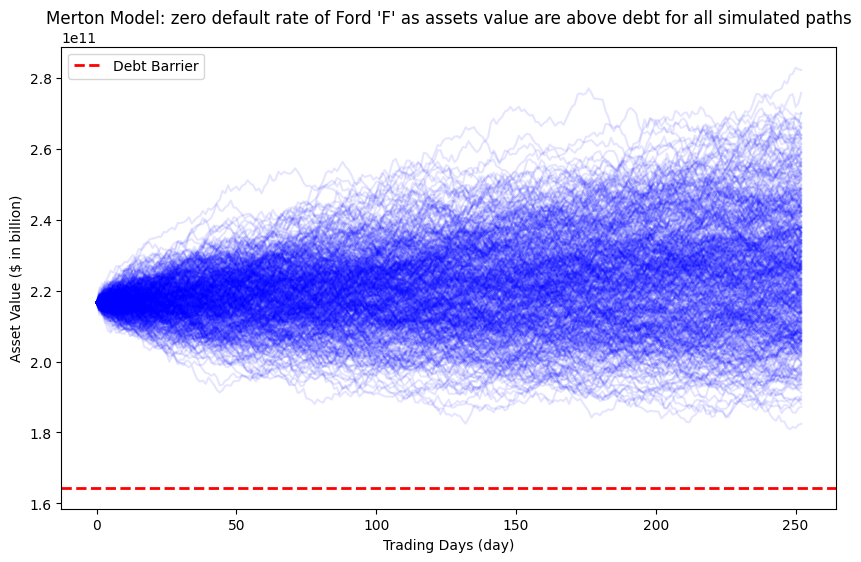

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ======================================================
# PART B: STRUCTURAL MODEL (Merton Distance to Default)
# ======================================================

# 1. INPUTS: Real Market Data
TICKER = "F"  # Ford Motor Co (High leverage example)
print(f"Fetching data for {TICKER}...")

# Get 1 Year of Data to calculate Trailing 12-M Volatility
stock = yf.Ticker(TICKER)
hist = stock.history(period="1y")

# A. Calculate User Variable: Trailing 12-Month Volatility (Annualized)
daily_returns = hist['Close'].pct_change().dropna()
# Std Dev of Daily Returns * Sqrt(252)
sigma_E = daily_returns.std() * np.sqrt(252)

# B. Calculate User Variable: Leverage (Debt / Capital)
# We need Total Debt (Book Value) and Market Cap
total_debt = stock.info.get('totalDebt')
market_cap = hist['Close'].iloc[-1] * stock.info.get('sharesOutstanding')
# Market Leverage = Debt / (Debt + Equity)
leverage_ratio = total_debt / (total_debt + market_cap)

print(f"\n--- Model Inputs for {TICKER} ---")
print(f"Market Cap (Equity):   ${market_cap/1e9:.2f} B")
print(f"Total Debt (Book):     ${total_debt/1e9:.2f} B")
print(f"Market Leverage Ratio: {leverage_ratio:.2%}")
print(f"Trailing 12-M Vol (Eq):{sigma_E:.2%}")

# 2. SOLVE FOR ASSET VALUE (V_A) & ASSET VOLATILITY (sigma_A)
# In Merton model, we observe Equity (Option), but need Asset parameters.
# Approximation: V_A = E + D, sigma_A = sigma_E * (E / V_A)
V_A = market_cap + total_debt
sigma_A = sigma_E * (market_cap / V_A)
r = 0.045 # Risk-free rate assumption (4.5%)
T = 1.0   # 1 Year horizon

# 3. MONTE CARLO SIMULATION
np.random.seed(42)
num_sims = 10000 # simulation path = 10,000
num_steps = 252 # 1 trading year
dt = T / num_steps

# Simulation Paths
# Assuming Asset Value moves randomly over time following Geometric Brownian Motion: dV = r*V*dt + sigma*V*dW
paths = np.zeros((num_steps + 1, num_sims))
paths[0] = V_A

for t in range(1, num_steps + 1):
    z = np.random.standard_normal(num_sims)
    # Drift is r (risk neutral)
    drift = (r - 0.5 * sigma_A**2) * dt
    shock = sigma_A * np.sqrt(dt) * z
    paths[t] = paths[t-1] * np.exp(drift + shock)

# 4. DETERMINE DEFAULT
# Default if Asset Value < Total Debt at maturity
ending_values = paths[-1]
defaults = ending_values < total_debt
pd_merton = np.mean(defaults)

print(f"\n--- Results ---")
print(f"Estimated Asset Volatility: {sigma_A:.2%}")
print(f"Structural Probability of Default (1Y): {pd_merton:.4%}")

# 5. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :500], alpha=0.1, color='blue') # Plot 500 paths
plt.axhline(y=total_debt, color='red', linestyle='--', linewidth=2, label='Debt Barrier')
plt.title(f"Merton Model: zero default rate of Ford '{TICKER}' as assets value are above debt for all simulated paths")
plt.xlabel("Trading Days (day)")
plt.ylabel("Asset Value ($ in billion)")
plt.legend()
plt.show()

In [17]:
print(f"\n--- Credit Strategy: Model-Derived vs. Market-Implied Probability of Default---")
print(f"")

def get_market_implied_pd(bond_yield, risk_free_rate, recovery_rate=0.40):
    """
    Calculates Market Implied PD from Bond Spreads (Proxy for CDS).

    Args:
        bond_yield (float): YTM of the corporate bond (e.g., 0.065 for 6.5%)
        risk_free_rate (float): Yield of matching Treasury (e.g., 0.040 for 4.0%)
        recovery_rate (float): Assumed Recovery Rate (Standard = 40%)

    Returns:
        float: Market Implied Probability of Default
    """
    spread = bond_yield - risk_free_rate

    # Simple Credit Triangle Formula: PD = Spread / (1 - R)
    implied_pd = spread / (1 - recovery_rate)

    # Handle negative spreads (rare arbitrage anomalies)
    return max(0.0, implied_pd)

# --- EXAMPLE USAGE IN YOUR NOTEBOOK ---
# 1. Real Data Lookup (Manual Step for Portfolio)
#    Source: FINRA TRACE
#    Ford Motor 2029 Bond Yield: ~6.375% (Example)
#    5Y Treasury Yield: ~4.37%
f_bond_yield = 0.06375
r_risk_free = 0.0437

# 2. Calculate Market Truth
market_pd = get_market_implied_pd(f_bond_yield, r_risk_free)

print(f"Market Implied PD: {market_pd:.2%}")
# Result: (6.375% - 4.37%) / 0.6 = ~3.34%

# 3. Compare with your Model
print(f"")

#case 1
model_pd = 0.0532 # Your Reduced Form Model result
print(f"If case 1 - Model PD: {model_pd:.2%}")

if model_pd > market_pd:
    print("Strategy: SHORT Bond (Model sees higher risk than Market)")
else:
    print("Strategy: LONG Bond (Model sees value)")

print(f"")

model_pd = 0.0286 # Your Reduced Form Model result
print(f"If case 2 - Model PD: {model_pd:.2%}")

if model_pd > market_pd:
    print("Strategy: SHORT Bond (Model sees higher risk than Market)")
else:
    print("Strategy: LONG Bond (Model sees lower risk than Market)")


--- Credit Strategy: Model-Derived vs. Market-Implied Probability of Default---

Market Implied PD: 3.34%

If case 1 - Model PD: 5.32%
Strategy: SHORT Bond (Model sees higher risk than Market)

If case 2 - Model PD: 2.86%
Strategy: LONG Bond (Model sees lower risk than Market)
